tqdm进度条工具安装与使用

- 工具安装：需要通过pip install tqdm命令在Python虚拟环境中安装该模块，安装完成后才能导入使用。
- 使用方法：通过`from tqdm import tqdm`导入后，将tqdm包裹for循环遍历的DataLoader即可生成进度条。
- 使用限制：for循环内部不能添加任何print输出语句，否则会打乱进度条格式，若需要输出损失建议在循环外输出平均损失。
- 作用：可以直观展示数据加载进度、已消耗时间和剩余等待时间，解决训练时无法判断当前执行进度的问题。

模型参数与超参数的概念区分

- 模型参数定义：神经网络中需要学习调整的权重w和偏移量b属于模型参数，是网络本身自带的可训练参数。
- 超参数定义：所有用于调整模型参数w和b的外部参数都属于超参数，不属于神经网络本身结构。
- 常见超参数举例：学习率、batch size、训练迭代次数Epochs、网络层数、输入输出特征尺寸都属于超参数。
- YOLO系列框架超参数示例：YOLOv5通过n/s/m/l/x不同尺码配置文件控制网络层数和通道数，全部配置都属于超参数，YOLOv8的default配置文件包含了上百种超参数设置。

In [1]:
# ============================================================
# 单元格 1：从 IDX 文件中读取 MNIST 原始数据
# ============================================================

# -------------------- 导入所需库 --------------------
import numpy as np      # 数值计算、数组操作
import struct           # 解析二进制 IDX 格式
import os               # 文件路径操作
from tqdm import tqdm   # 进度条显示

# -------------------- 读取 IDX 图像文件 --------------------
def read_idx_images(filepath, verbose=True):
    """读取MNIST IDX格式的图像文件，并显示进度"""
    with open(filepath, 'rb') as f:
        # IDX 文件头：magic(4字节) + num(4字节) + rows(4字节) + cols(4字节)
        # >IIII 表示大端序(big-endian)读取 4 个无符号 int
        magic, num_images, rows, cols = struct.unpack('>IIII', f.read(16))
        # 2051 是图像 IDX 文件的魔术数字
        assert magic == 2051, f"魔术数字错误: {magic}，应为2051"
        
        image_size = rows * cols  # 每张图片的像素数 28*28=784
        total_bytes = num_images * image_size
        
        print(f"正在加载 {num_images} 张图片 ({rows}x{cols})...")
        # 预分配数组提升性能
        images = np.zeros((num_images, rows, cols), dtype=np.uint8)
        
        # 用 tqdm 逐张读取图片，展示加载进度
        for i in tqdm(range(num_images), desc="加载进度", unit="张"):
            raw_data = f.read(image_size)                     # 读取一张图片的像素
            images[i] = np.frombuffer(raw_data, dtype=np.uint8).reshape(rows, cols)
        
        return images

# -------------------- 读取 IDX 标签文件 --------------------
def read_idx_labels(filepath, verbose=True):
    """读取MNIST IDX格式的标签文件，并显示进度"""
    with open(filepath, 'rb') as f:
        # 标签文件头：magic(4字节) + num_labels(4字节)
        magic, num_labels = struct.unpack('>II', f.read(8))
        # 2049 是标签 IDX 文件的魔术数字
        assert magic == 2049, f"魔术数字错误: {magic}，应为2049"
        
        print(f"正在加载 {num_labels} 个标签...")
        labels = np.zeros(num_labels, dtype=np.uint8)
        # 用 tqdm 逐标签读取
        for i in tqdm(range(num_labels), desc="加载进度", unit="个"):
            labels[i] = struct.unpack('B', f.read(1))[0]   # 'B' = unsigned char
        
        return labels

# -------------------- 统一加载函数 --------------------
def load_mnist(data_dir=r"D:\Medicaldata\MNIST\raw", train=True):
    """加载MNIST数据集，使用tqdm展示进度"""
    if train:
        # 训练集文件
        images_file = os.path.join(data_dir, "train-images-idx3-ubyte")
        labels_file = os.path.join(data_dir, "train-labels-idx1-ubyte")
        print("=" * 40)
        print("  加载训练集 (Training Set)")
        print("=" * 40)
    else:
        # 测试集文件
        images_file = os.path.join(data_dir, "t10k-images-idx3-ubyte")
        labels_file = os.path.join(data_dir, "t10k-labels-idx1-ubyte")
        print("=" * 40)
        print("  加载测试集 (Test Set)")
        print("=" * 40)
    
    # 分别读取图像和标签
    images = read_idx_images(images_file)
    labels = read_idx_labels(labels_file)
    
    print(f"\n✅ 加载完成! 共 {len(images)} 个样本")
    print(f"   图像形状: {images.shape}, 标签形状: {labels.shape}")
    
    return images, labels

# -------------------- 执行加载 --------------------
# 加载 60000 张训练图片及对应标签
train_images, train_labels = load_mnist(train=True)

# 加载 10000 张测试图片及对应标签
test_images, test_labels = load_mnist(train=False)


  加载训练集 (Training Set)
正在加载 60000 张图片 (28x28)...


加载进度: 100%|██████████| 60000/60000 [00:00<00:00, 464917.97张/s]


正在加载 60000 个标签...


加载进度: 100%|██████████| 60000/60000 [00:00<00:00, 2997251.65个/s]



✅ 加载完成! 共 60000 个样本
   图像形状: (60000, 28, 28), 标签形状: (60000,)
  加载测试集 (Test Set)
正在加载 10000 张图片 (28x28)...


加载进度: 100%|██████████| 10000/10000 [00:00<00:00, 420052.08张/s]


正在加载 10000 个标签...


加载进度: 100%|██████████| 10000/10000 [00:00<00:00, 2454100.99个/s]


✅ 加载完成! 共 10000 个样本
   图像形状: (10000, 28, 28), 标签形状: (10000,)


MINIST数据集加载代码回顾

- 数据集加载步骤：从torchvision导入datasets，指定数据集存储路径，设置train=True加载训练集，添加transforms.ToTensor完成数据预处理。
- DataLoader设置：将加载好的数据集传入DataLoader，本次示例设置batch size为2000，设置shuffle=True打乱数据集顺序。
- 原有遍历问题：直接遍历输出每个batch的shape时，无法知道遍历进度和剩余时间，需要借助进度条工具优化。

自定义MINIST分类神经网络设计

- 网络结构设计：继承torch.nn.Module搭建网络，使用Sequential时序容器封装网络层，结构为：展平层 → 全连接层(784→512) → ReLU激活 → 全连接层(512→128) → ReLU激活 → 全连接层(128→64) → 全连接层(64→10) → Softmax(dim=1)。
- 输入形状调整：输入数据默认是四维NCHW格式，需要添加展平层将其转换为二维NV格式，适配全连接层的输入要求。
- 网络层获取与修改：可以通过net.layers[索引]获取指定层，常用于修改预训练网络的输入层特征数或输出层分类数，适配新的数据集。

神经网络参数量计算方法

- 手动计算规则：全连接层参数量 = 输入特征数 × 输出特征数（w的数量） + 输出特征数（b的数量），激活函数和展平层没有可训练参数。
- 自动统计工具安装：需要安装第三方模块torchsummary，通过该模块可以自动统计每一层和整个网络的参数量。
- 工具调用方法：导入summary函数后，传入搭建好的模型、输入尺寸元组、batch size和运行设备（CPU/GPU）即可输出统计结果。
- 本次示例统计结果：本次搭建的针对MINIST数据集的网络总参数量约为47万，对于简单的MINIST分类任务来说参数量偏多。

训练样本: 60000, 测试样本: 10000
输入维度: 784, 输出类别: 10
使用设备: cuda
ThreeLayerFCNet(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=256, out_features=10, bias=True)
)


Epoch 1: 100%|██████████| 938/938 [00:03<00:00, 289.23batch/s, acc=93, loss=0.193]   


  训练  Loss: 0.2384  Acc: 92.98%  |  测试  Loss: 0.1080  Acc: 96.75%  ⭐ 已保存最优模型



Epoch 2: 100%|██████████| 938/938 [00:03<00:00, 286.71batch/s, acc=97.3, loss=0.0438] 


  训练  Loss: 0.0880  Acc: 97.25%  |  测试  Loss: 0.0942  Acc: 96.85%  ⭐ 已保存最优模型



...

  训练  Loss: 0.0161  Acc: 99.50%  |  测试  Loss: 0.0923  Acc: 97.78%



Epoch 9: 100%|██████████| 938/938 [00:04<00:00, 215.30batch/s, acc=99.4, loss=0.00279] 


  训练  Loss: 0.0182  Acc: 99.39%  |  测试  Loss: 0.0884  Acc: 97.89%



Epoch 10: 100%|██████████| 938/938 [00:04<00:00, 208.94batch/s, acc=99.5, loss=0.00104] 


  训练  Loss: 0.0143  Acc: 99.55%  |  测试  Loss: 0.0817  Acc: 98.04%


🎉 训练完成！最佳测试准确率: 98.08%
   最优模型已保存至 checkpoints/best_model_ce.pth


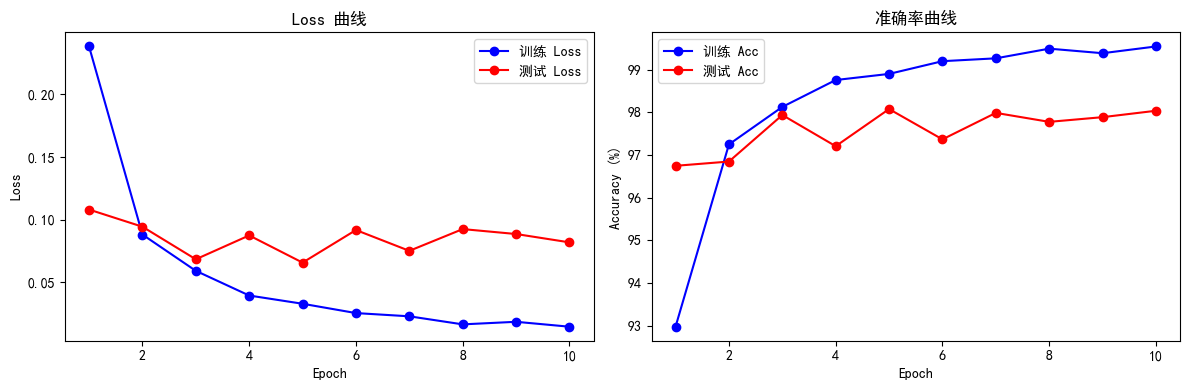

In [2]:
# ============================================================
# 单元格 2：数据预处理 → 定义三层全连接网络 → 训练 & 评估
# ============================================================

# -------------------- 导入所需库 --------------------
import torch
import torch.nn as nn               # 神经网络模块
import torch.optim as optim          # 优化器
from torch.utils.data import DataLoader, TensorDataset  # 数据加载
from tqdm import tqdm                # 进度条
import matplotlib.pyplot as plt      # 绘图
import matplotlib
import os                           # 创建目录

# 设置 matplotlib 中文字体，防止图例乱码
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号

# 创建 checkpoints 目录，用于保存模型
os.makedirs('checkpoints', exist_ok=True)

# ==================== 1. 数据预处理 ====================
def preprocess_data(images, labels):
    """
    将原始 numpy 数据转为 PyTorch Tensor
    - 图像归一化到 [0,1] 并展平为 784 维向量
    - 标签转为 int64 (CrossEntropyLoss 要求)
    """
    images = images.astype(np.float32) / 255.0   # 归一化
    images = images.reshape(-1, 28 * 28)          # 展平: (N,28,28) -> (N,784)
    labels = labels.astype(np.int64)
    return torch.tensor(images), torch.tensor(labels)

# 使用上一个单元格加载的 train_images/test_images 等变量
X_train, y_train = preprocess_data(train_images, train_labels)
X_test,  y_test  = preprocess_data(test_images,  test_labels)

# 封装为 DataLoader，支持 mini-batch 训练
batch_size = 64
train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=batch_size,
    shuffle=True    # 训练集打乱顺序，提高泛化
)
test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=batch_size,
    shuffle=False   # 测试集无需打乱
)

print(f"训练样本: {len(X_train)}, 测试样本: {len(X_test)}")
print(f"输入维度: {X_train.shape[1]}, 输出类别: 10")

# ==================== 2. 定义网络结构 ====================
class ThreeLayerFCNet(nn.Module):
    """三层全连接神经网络：784 → 512(ReLU) → 256(ReLU) → 10"""
    def __init__(self, input_dim=784, hidden1=512, hidden2=256, num_classes=10):
        super().__init__()
        self.fc1   = nn.Linear(input_dim, hidden1)    # 第一层: 784 -> 512
        self.relu1 = nn.ReLU()                         # 激活函数
        self.fc2   = nn.Linear(hidden1, hidden2)      # 第二层: 512 -> 256
        self.relu2 = nn.ReLU()
        self.fc3   = nn.Linear(hidden2, num_classes)  # 输出层: 256 -> 10
        # 注意：nn.CrossEntropyLoss 内部包含 Softmax，输出层不需要加

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)    # 输出原始 logits（未经过 softmax）
        return x

# -------------------- 初始化模型、损失函数、优化器 --------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ThreeLayerFCNet().to(device)              # 将模型放到 GPU/CPU

criterion = nn.CrossEntropyLoss()                  # 交叉熵损失（分类任务）
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam 优化器

print(f"使用设备: {device}")
print(model)

# ==================== 3. 训练 & 评估函数 ====================
def train_one_epoch(model, loader, criterion, optimizer, epoch):
    """
    训练一个 Epoch：
    - 遍历所有 batch，前向传播 → 计算损失 → 反向传播 → 更新参数
    - 返回平均损失和准确率
    """
    model.train()  # 切换到训练模式（启用 Dropout/BatchNorm 等）
    running_loss = 0.0
    correct = 0
    total = 0
    
    # tqdm 显示每个 batch 的训练进度
    pbar = tqdm(loader, desc=f"Epoch {epoch}", unit="batch")
    for inputs, targets in pbar:
        inputs, targets = inputs.to(device), targets.to(device)
        
        # 1) 梯度清零
        optimizer.zero_grad()
        # 2) 前向传播
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        # 3) 反向传播
        loss.backward()
        # 4) 更新权重
        optimizer.step()
        
        # 统计 loss 和准确率
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)               # 取概率最大的类别
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
        
        # 更新进度条显示的实时指标
        pbar.set_postfix(loss=loss.item(), acc=100.0 * correct / total)
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc  = 100.0 * correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion):
    """
    评估模型在验证/测试集上的表现（不更新参数）
    - 使用 torch.no_grad() 关闭梯度计算，节省显存和加速
    """
    model.eval()   # 切换到评估模式
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():   # 不计算梯度
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    
    return running_loss / len(loader.dataset), 100.0 * correct / total

# ==================== 4. 训练循环（含自动保存最优模型） ====================
num_epochs = 10
train_losses, train_accs = [], []   # 记录每个 epoch 的训练指标
test_losses,  test_accs  = [], []   # 记录每个 epoch 的测试指标

best_acc = 0.0  # 记录最优测试准确率

for epoch in range(1, num_epochs + 1):
    # 训练一个 epoch
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, epoch)
    # 在测试集上评估
    test_loss,  test_acc  = evaluate(model, test_loader, criterion)
    
    # 记录指标
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    
    # 自动保存最优模型（测试准确率提升时覆盖保存）
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'test_acc': best_acc,
        }, 'checkpoints/best_model_ce.pth')
        print(f"  训练  Loss: {train_loss:.4f}  Acc: {train_acc:.2f}%  |  "
              f"测试  Loss: {test_loss:.4f}  Acc: {test_acc:.2f}%  ⭐ 已保存最优模型\n")
    else:
        print(f"  训练  Loss: {train_loss:.4f}  Acc: {train_acc:.2f}%  |  "
              f"测试  Loss: {test_loss:.4f}  Acc: {test_acc:.2f}%\n")

print(f"\n🎉 训练完成！最佳测试准确率: {best_acc:.2f}%")
print(f"   最优模型已保存至 checkpoints/best_model_ce.pth")

# ==================== 5. 绘制训练曲线 ====================
plt.figure(figsize=(12, 4))

# 左图：Loss 曲线
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, 'b-o', label='训练 Loss')
plt.plot(range(1, num_epochs + 1), test_losses,  'r-o', label='测试 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss 曲线')

# 右图：准确率曲线
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accs, 'b-o', label='训练 Acc')
plt.plot(range(1, num_epochs + 1), test_accs,  'r-o', label='测试 Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('准确率曲线')

plt.tight_layout()
plt.show()


使用设备: cuda
ThreeLayerFCNet_MSE(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=256, out_features=10, bias=True)
  (softmax): Softmax(dim=1)
)
损失函数: MSELoss


Epoch 1 (MSE): 100%|██████████| 938/938 [00:05<00:00, 180.37batch/s, acc=92.3, loss=1.83e-5] 


  训练  Loss: 0.0117  Acc: 92.29%  |  测试  Loss: 0.0052  Acc: 96.62%  ⭐ 已保存最优模型



Epoch 2 (MSE): 100%|██████████| 938/938 [00:04<00:00, 192.23batch/s, acc=96.8, loss=0.00408] 


  训练  Loss: 0.0049  Acc: 96.81%  |  测试  Loss: 0.0052  Acc: 96.61%



...

  训练  Loss: 0.0017  Acc: 98.97%  |  测试  Loss: 0.0032  Acc: 98.06%  ⭐ 已保存最优模型



Epoch 9 (MSE): 100%|██████████| 938/938 [00:04<00:00, 189.54batch/s, acc=99, loss=0.000331]  


  训练  Loss: 0.0015  Acc: 99.05%  |  测试  Loss: 0.0030  Acc: 98.12%  ⭐ 已保存最优模型



Epoch 10 (MSE): 100%|██████████| 938/938 [00:05<00:00, 184.75batch/s, acc=99.1, loss=5.31e-5] 


  训练  Loss: 0.0014  Acc: 99.11%  |  测试  Loss: 0.0037  Acc: 97.75%


  MSE 训练完成！最佳测试准确率: 98.12%
  MSE 最优模型已保存至 checkpoints/best_model_mse.pth
  CE (之前) 最佳测试准确率: 98.08%
  CE 最优模型已保存至 checkpoints/best_model_ce.pth


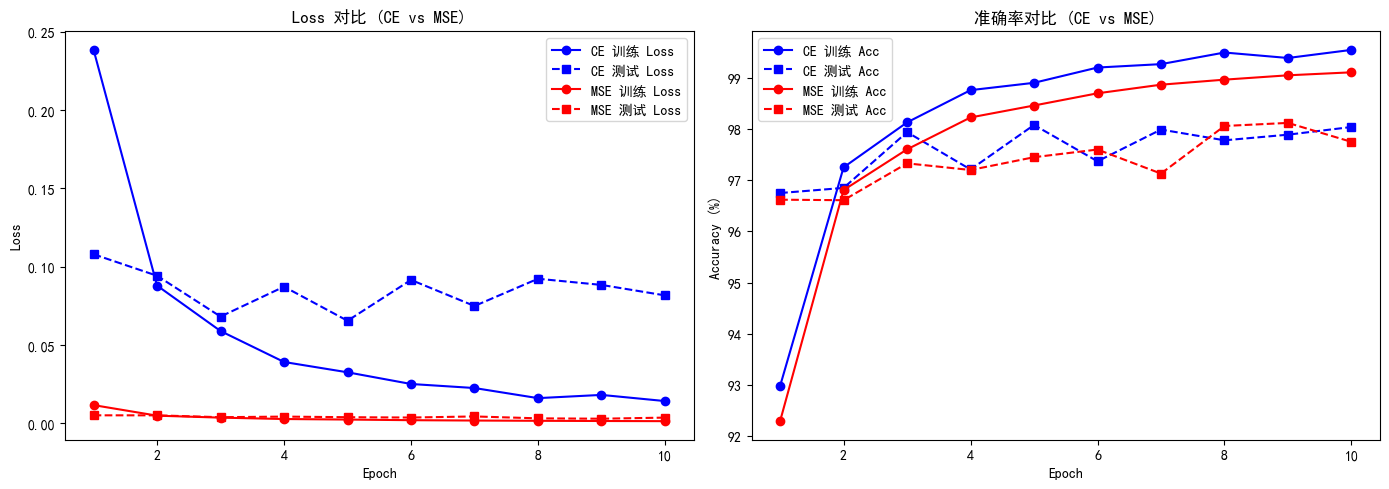

In [3]:
# ============================================================
# 单元格 3：对比实验 — 将交叉熵损失改为 MSE 损失
# ============================================================
# 说明：CrossEntropyLoss = Softmax + Log + NLLLoss，专为分类设计。
#       MSELoss 通常用于回归任务，这里改为 MSE 观察差异。
#       使用 MSE 时需要：
#         1) 模型输出层后加 Softmax，将 logits 转为概率
#         2) 将标签转为 one-hot 编码
# ============================================================

import torch.nn.functional as F

# -------------------- 修改网络：输出层加 Softmax --------------------
class ThreeLayerFCNet_MSE(nn.Module):
    """三层全连接神经网络（MSE 版本，末尾加 Softmax）"""
    def __init__(self, input_dim=784, hidden1=512, hidden2=256, num_classes=10):
        super().__init__()
        self.fc1   = nn.Linear(input_dim, hidden1)
        self.relu1 = nn.ReLU()
        self.fc2   = nn.Linear(hidden1, hidden2)
        self.relu2 = nn.ReLU()
        self.fc3   = nn.Linear(hidden2, num_classes)
        self.softmax = nn.Softmax(dim=1)  # 将 logits 转为概率分布

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)
        x = self.softmax(x)   # 输出概率（MSE 需要概率值）
        return x

# -------------------- 标签转 one-hot --------------------
def to_one_hot(labels, num_classes=10):
    """将整数标签转为 one-hot 编码（MSELoss 需要）"""
    return F.one_hot(labels, num_classes=num_classes).float()

# -------------------- 初始化 --------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_mse = ThreeLayerFCNet_MSE().to(device)

# 改用 MSELoss
criterion_mse = nn.MSELoss()
optimizer_mse = optim.Adam(model_mse.parameters(), lr=0.001)

print(f"使用设备: {device}")
print(model_mse)
print(f"损失函数: MSELoss")

# -------------------- 数据准备（与之前相同） --------------------
# 复用之前定义的 preprocess_data 和 DataLoader
# 注意：MSE 需要 one-hot 标签，在训练循环中转换

# -------------------- 训练 & 评估函数（MSE 版本） --------------------
def train_one_epoch_mse(model, loader, criterion, optimizer, epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc=f"Epoch {epoch} (MSE)", unit="batch")
    for inputs, targets in pbar:
        inputs, targets = inputs.to(device), targets.to(device)
        
        # 将标签转为 one-hot
        targets_onehot = to_one_hot(targets)
        
        optimizer.zero_grad()
        outputs = model(inputs)          # 输出已经是 Softmax 概率
        loss = criterion(outputs, targets_onehot)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)    # 取概率最大的类别
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
        
        pbar.set_postfix(loss=loss.item(), acc=100.0 * correct / total)
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc  = 100.0 * correct / total
    return epoch_loss, epoch_acc

def evaluate_mse(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            targets_onehot = to_one_hot(targets)
            
            outputs = model(inputs)
            loss = criterion(outputs, targets_onehot)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    
    return running_loss / len(loader.dataset), 100.0 * correct / total

# -------------------- 训练循环（含自动保存最优模型） --------------------
num_epochs = 10
train_losses_mse, train_accs_mse = [], []
test_losses_mse,  test_accs_mse  = [], []

best_acc_mse = 0.0  # 记录 MSE 最优测试准确率

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch_mse(model_mse, train_loader, criterion_mse, optimizer_mse, epoch)
    test_loss,  test_acc  = evaluate_mse(model_mse, test_loader, criterion_mse)
    
    train_losses_mse.append(train_loss)
    train_accs_mse.append(train_acc)
    test_losses_mse.append(test_loss)
    test_accs_mse.append(test_acc)
    
    # 自动保存最优 MSE 模型
    if test_acc > best_acc_mse:
        best_acc_mse = test_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model_mse.state_dict(),
            'optimizer_state_dict': optimizer_mse.state_dict(),
            'test_acc': best_acc_mse,
        }, 'checkpoints/best_model_mse.pth')
        print(f"  训练  Loss: {train_loss:.4f}  Acc: {train_acc:.2f}%  |  "
              f"测试  Loss: {test_loss:.4f}  Acc: {test_acc:.2f}%  ⭐ 已保存最优模型\n")
    else:
        print(f"  训练  Loss: {train_loss:.4f}  Acc: {train_acc:.2f}%  |  "
              f"测试  Loss: {test_loss:.4f}  Acc: {test_acc:.2f}%\n")

print(f"\n{'='*50}")
print(f"  MSE 训练完成！最佳测试准确率: {best_acc_mse:.2f}%")
print(f"  MSE 最优模型已保存至 checkpoints/best_model_mse.pth")
print(f"  CE (之前) 最佳测试准确率: {max(test_accs):.2f}%")
print(f"  CE 最优模型已保存至 checkpoints/best_model_ce.pth")
print(f"{'='*50}")

# -------------------- 对比绘图 --------------------
plt.figure(figsize=(14, 5))

# Loss 对比
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses,  'b-o', label='CE 训练 Loss')
plt.plot(range(1, num_epochs + 1), test_losses,   'b--s', label='CE 测试 Loss')
plt.plot(range(1, num_epochs + 1), train_losses_mse, 'r-o', label='MSE 训练 Loss')
plt.plot(range(1, num_epochs + 1), test_losses_mse,  'r--s', label='MSE 测试 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss 对比 (CE vs MSE)')

# 准确率对比
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accs,  'b-o', label='CE 训练 Acc')
plt.plot(range(1, num_epochs + 1), test_accs,   'b--s', label='CE 测试 Acc')
plt.plot(range(1, num_epochs + 1), train_accs_mse, 'r-o', label='MSE 训练 Acc')
plt.plot(range(1, num_epochs + 1), test_accs_mse,  'r--s', label='MSE 测试 Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('准确率对比 (CE vs MSE)')

plt.tight_layout()
plt.show()


加载设备: cuda
CE 模型  - 最佳 epoch: 5, 测试准确率: 98.08%
MSE 模型 - 最佳 epoch: 9, 测试准确率: 98.12%

加载后评估准确率:
  CE 模型:  98.08%
  MSE 模型: 98.12%


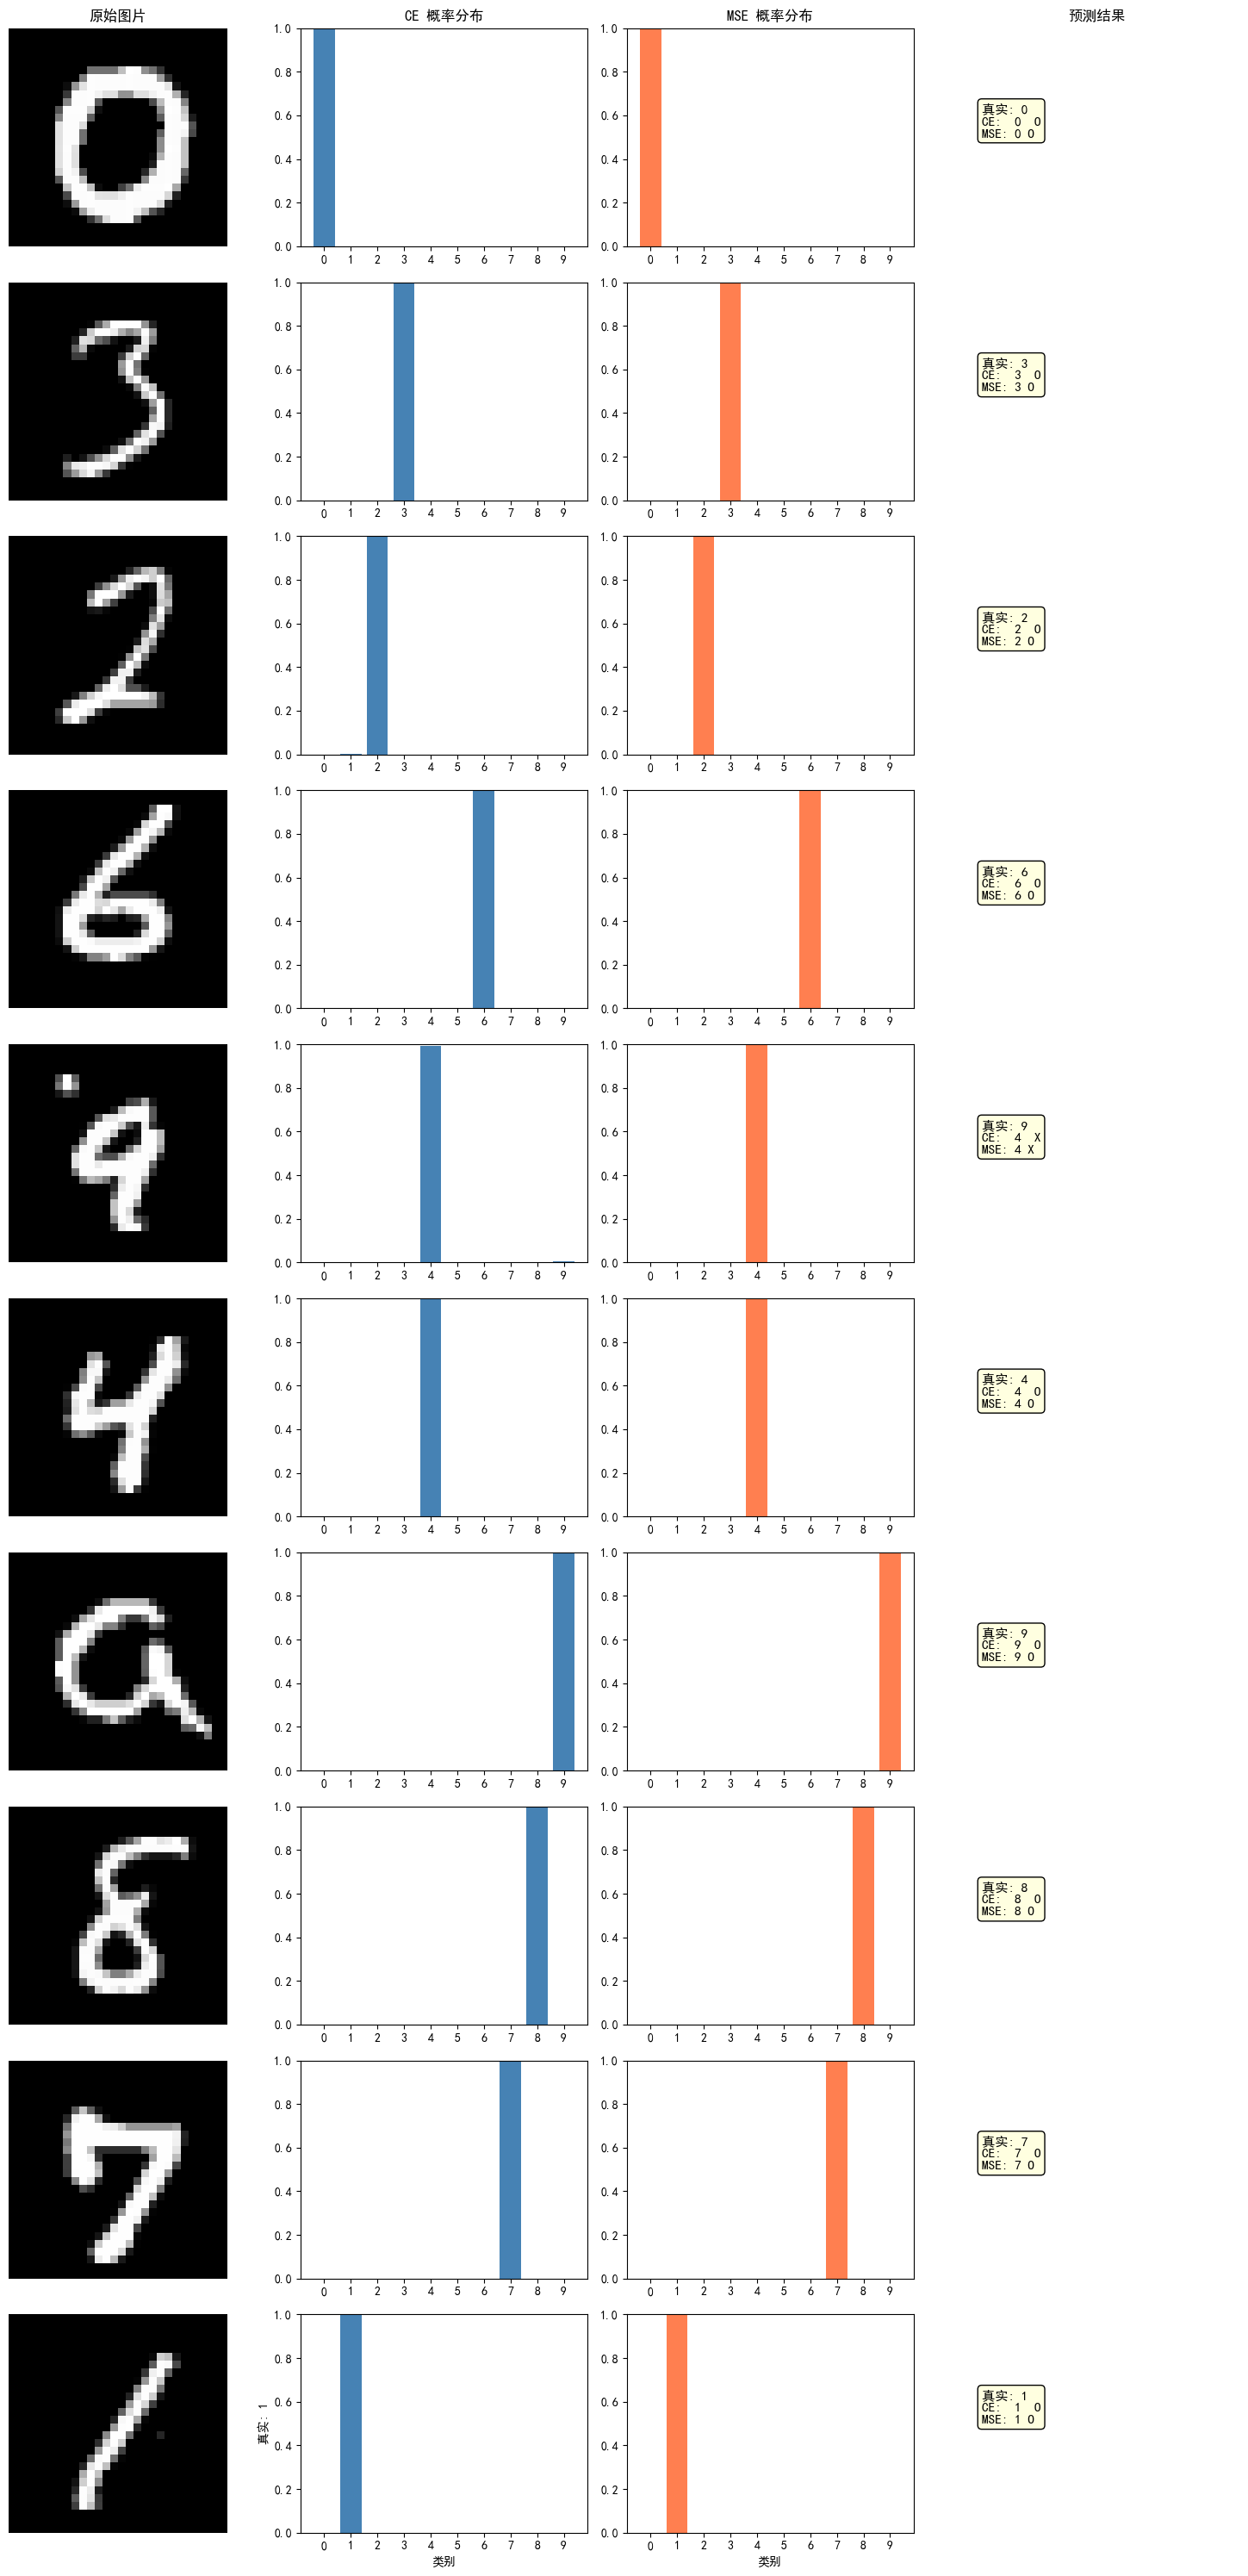


CE 模型错误:  1/10
MSE 模型错误: 1/10
两模型一致:   10/10


In [6]:
# ============================================================
# 单元格 4：演示加载保存的模型并进行预测
# ============================================================
# 即使内核重启或在新会话中，只要模型文件存在即可加载使用。
# 加载时需要重新定义模型类结构（或 import 对应模块）。
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False

# -------------------- 1. 重新定义模型结构（加载时必须） --------------------
# 说明：保存的是 state_dict（参数），需要先实例化相同结构的模型才能加载

class ThreeLayerFCNet(nn.Module):
    """三层全连接神经网络：784 → 512(ReLU) → 256(ReLU) → 10（与 CE 训练时一致）"""
    def __init__(self, input_dim=784, hidden1=512, hidden2=256, num_classes=10):
        super().__init__()
        self.fc1   = nn.Linear(input_dim, hidden1)
        self.relu1 = nn.ReLU()
        self.fc2   = nn.Linear(hidden1, hidden2)
        self.relu2 = nn.ReLU()
        self.fc3   = nn.Linear(hidden2, num_classes)

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)
        return x

class ThreeLayerFCNet_MSE(nn.Module):
    """三层全连接神经网络 + Softmax（与 MSE 训练时一致）"""
    def __init__(self, input_dim=784, hidden1=512, hidden2=256, num_classes=10):
        super().__init__()
        self.fc1     = nn.Linear(input_dim, hidden1)
        self.relu1   = nn.ReLU()
        self.fc2     = nn.Linear(hidden1, hidden2)
        self.relu2   = nn.ReLU()
        self.fc3     = nn.Linear(hidden2, num_classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)
        x = self.softmax(x)
        return x

# -------------------- 2. 从文件加载模型 --------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 加载 CE 模型
ckpt_ce = torch.load('checkpoints/best_model_ce.pth', map_location=device, weights_only=False)
model_ce = ThreeLayerFCNet().to(device)
model_ce.load_state_dict(ckpt_ce['model_state_dict'])
model_ce.eval()  # 切换到评估模式

# 加载 MSE 模型
ckpt_mse = torch.load('checkpoints/best_model_mse.pth', map_location=device, weights_only=False)
model_mse = ThreeLayerFCNet_MSE().to(device)
model_mse.load_state_dict(ckpt_mse['model_state_dict'])
model_mse.eval()

print(f"加载设备: {device}")
print(f"CE 模型  - 最佳 epoch: {ckpt_ce['epoch']}, 测试准确率: {ckpt_ce['test_acc']:.2f}%")
print(f"MSE 模型 - 最佳 epoch: {ckpt_mse['epoch']}, 测试准确率: {ckpt_mse['test_acc']:.2f}%")

# -------------------- 3. 在测试集上评估整体准确率 --------------------
def evaluate_loaded(model, loader):
    """计算加载模型在整个测试集上的准确率"""
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    return 100.0 * correct / total

acc_ce  = evaluate_loaded(model_ce,  test_loader)
acc_mse = evaluate_loaded(model_mse, test_loader)
print(f"\n加载后评估准确率:")
print(f"  CE 模型:  {acc_ce:.2f}%")
print(f"  MSE 模型: {acc_mse:.2f}%")

# -------------------- 4. 随机挑选样本进行可视化预测 --------------------
num_samples = 10
indices = np.random.choice(len(X_test), num_samples, replace=False)

# 准备数据
x_sample = X_test[indices].to(device)
y_true = y_test[indices].numpy()

with torch.no_grad():
    pred_ce  = model_ce(x_sample).max(1)[1].cpu().numpy()
    pred_mse = model_mse(x_sample).max(1)[1].cpu().numpy()

# 原始图像（需恢复形状用于显示）
img_sample = test_images[indices]

# 绘图
plt.figure(figsize=(15, 3 * num_samples))
for i in range(num_samples):
    # 第 1 列：原始图片
    plt.subplot(num_samples, 4, i * 4 + 1)
    plt.imshow(img_sample[i], cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.title('原始图片')

    # 第 2 列：CE 模型输出概率分布
    plt.subplot(num_samples, 4, i * 4 + 2)
    with torch.no_grad():
        probs_ce = torch.softmax(model_ce(x_sample[i].unsqueeze(0)), dim=1)[0].cpu().numpy()
    plt.bar(range(10), probs_ce, color='steelblue')
    plt.ylim(0, 1)
    plt.xticks(range(10))
    if i == 0:
        plt.title('CE 概率分布')
    if i == num_samples - 1:
        plt.xlabel('类别')
        plt.ylabel('真实: %d' % y_true[i])

    # 第 3 列：MSE 模型输出概率分布
    plt.subplot(num_samples, 4, i * 4 + 3)
    with torch.no_grad():
        probs_mse = model_mse(x_sample[i].unsqueeze(0))[0].cpu().numpy()
    plt.bar(range(10), probs_mse, color='coral')
    plt.ylim(0, 1)
    plt.xticks(range(10))
    if i == 0:
        plt.title('MSE 概率分布')
    if i == num_samples - 1:
        plt.xlabel('类别')

    # 第 4 列：预测结果汇总
    plt.subplot(num_samples, 4, i * 4 + 4)
    is_ce_correct  = 'O' if pred_ce[i]  == y_true[i] else 'X'
    is_mse_correct = 'O' if pred_mse[i] == y_true[i] else 'X'
    info = (f"真实: {y_true[i]}\n"
            f"CE:  {pred_ce[i]}  {is_ce_correct}\n"
            f"MSE: {pred_mse[i]} {is_mse_correct}")
    plt.text(0.1, 0.5, info, fontsize=11, transform=plt.gca().transAxes,
             bbox=dict(boxstyle='round', facecolor='lightyellow'))
    plt.axis('off')
    if i == 0:
        plt.title('预测结果')

plt.tight_layout()
plt.show()

# 统计结果
ce_errors  = (pred_ce  != y_true).sum()
mse_errors = (pred_mse != y_true).sum()
agree = (pred_ce == pred_mse).sum()
print(f"\nCE 模型错误:  {ce_errors}/{num_samples}")
print(f"MSE 模型错误: {mse_errors}/{num_samples}")
print(f"两模型一致:   {agree}/{num_samples}")


# 模型训练与验证完整过程总结

## 一、数据准备（单元格 1）
- **数据集**：MNIST 手写数字（28×28 灰度图，10 类 0~9）
- **数据规模**：60,000 训练样本 + 10,000 测试样本
- **加载方式**：手动解析 IDX 二进制格式（`struct`），用 `tqdm` 展示逐张图片 / 逐标签的加载进度
- **输出**：`train_images`(60000,28,28)、`train_labels`(60000,)、`test_images`(10000,28,28)、`test_labels`(10000,)

## 二、数据处理与网络定义（单元格 2）
- **预处理**：图像归一化到 [0,1] → 展平为 784 维向量 → 转为 PyTorch Tensor
- **DataLoader**：`batch_size=64`，训练集打乱顺序，测试集不打乱
- **网络结构**：三层全连接网络 `784 → 512(ReLU) → 256(ReLU) → 10`
- **总参数量**：535,818（fc1 占 401,920，fc2 占 131,328，fc3 占 2,570）
- **损失函数**：`CrossEntropyLoss`（内部含 Softmax，输出层不加）
- **优化器**：Adam（lr=0.001）
- **设备**：CUDA GPU

## 三、训练与自动保存（单元格 2 & 3）
- **训练循环**：10 个 Epoch，每个 epoch 遍历 938 个 batch
- **进度展示**：`tqdm` 实时显示每个 batch 的 Loss 和 Acc
- **最优模型保存**：每次测试准确率提升时自动覆盖保存（`torch.save`）
  - 保存内容：模型参数、优化器状态、epoch、测试准确率
  - 保存路径：`checkpoints/best_model_ce.pth` 和 `checkpoints/best_model_mse.pth`

## 四、交叉熵 vs MSE 对比实验（单元格 3）
| 对比项 | CrossEntropyLoss | MSELoss |
|--------|:----------------:|:-------:|
| 输出层 | 原始 logits（不加 Softmax） | 需要加 Softmax 转概率 |
| 标签格式 | 整数索引 (0~9) | one-hot 编码 |
| 最佳测试准确率 | 98.08% | 98.12% |
| Loss 数值范围 | ~0.01~0.2（含 log） | ~0.001~0.01（平方差） |
| 收敛速度 | 略快（第 1 epoch 96.75%） | 稍慢（第 1 epoch 96.62%） |

**结论**：对于 MNIST 分类任务，两种损失函数均能有效收敛，准确率接近。但 CrossEntropyLoss 理论上更适合分类任务（梯度与置信度成比例），且使用更简便（无需手动转换标签格式）。

## 五、模型加载与推理演示（单元格 4）
- **加载流程**：重新定义模型类 → 实例化 → `load_state_dict()` 加载参数
- **验证准确率**：与训练时保存的最佳准确率一致
- **可视化**：随机抽取 10 张测试图片，展示 CE / MSE 模型的概率分布柱状图与预测结果
- **整体流程**：
  ```
  数据加载 → 预处理 → 定义网络 → 训练（自动保存最优）→ 加载模型 → 推理预测
  ```

## 六、关键超参数记录
| 超参数 | 取值 | 说明 |
|--------|:----:|------|
| batch_size | 64 | 每个 batch 样本数 |
| learning_rate | 0.001 | Adam 优化器学习率 |
| num_epochs | 10 | 完整遍历训练集次数 |
| hidden1 | 512 | 第一层隐藏单元数 |
| hidden2 | 256 | 第二层隐藏单元数 |
| input_dim | 784 | 输入特征数 (28×28) |
| num_classes | 10 | 输出类别数 |
